---

In [77]:
import numpy as np
import matplotlib.pyplot as plt

---

# Two-Mirror Concentrator

In [78]:
flat_source, flat_target, radius, f1, L, f2, da, a_max = np.loadtxt('data_finite/input.csv', delimiter = ',')
mirror1a = np.loadtxt('data_finite/mirror1a.csv', delimiter = ',')
mirror1b = np.loadtxt('data_finite/mirror1b.csv', delimiter = ',')
mirror2a = np.loadtxt('data_finite/mirror2a.csv', delimiter = ',')
mirror2b = np.loadtxt('data_finite/mirror2b.csv', delimiter = ',')

source = 'flat' if flat_source else 'cylindrical'
target = 'flat' if flat_target else 'cylindrical'
if (f1 == f2): print(f'symmetric system: {source} source -> {target} target')
else: print(f'asymmetric system: {source} source -> {target} target')
print(f'radius = {radius}, f1 = {f1}, L = {L}, f2 = {f2}, da = {da:.6f}, a_max = {a_max}')

symmetric system: cylindrical source -> cylindrical target
radius = 0.001, f1 = 1.0, L = 4.0, f2 = 1.0, da = 0.000001, a_max = 120.0


/Users/bcolussi/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


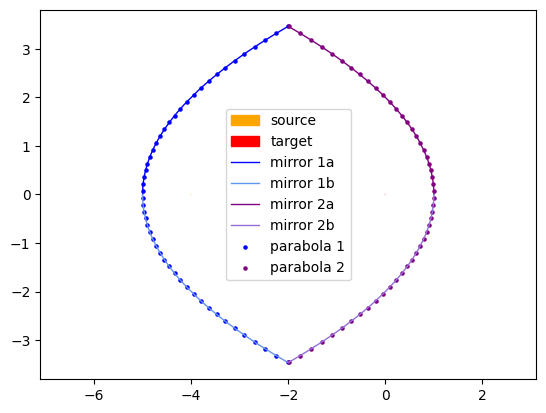

In [79]:
# source and target
if flat_source: plt.plot([-L, -L], [-radius, radius], linewidth = 5, color = 'orange', label = 'source')
else: plt.gca().add_patch(plt.Circle((-L, 0), radius, color = 'orange', label = 'source'))
if flat_target: plt.plot([0, 0], [-radius, radius], linewidth = 5, color = 'red', label = 'target')
else: plt.gca().add_patch(plt.Circle((0, 0), radius, color = 'red', label = 'target'))

# mirrors
plt.plot(mirror1a[:, 0], mirror1a[:, 1], linewidth = 1, c = 'blue', label = 'mirror 1a')
plt.plot(mirror1b[:, 0], mirror1b[:, 1], linewidth = 1, c = 'cornflowerblue', label = 'mirror 1b')
plt.plot(mirror2a[:, 0], mirror2a[:, 1], linewidth = 1, c = 'purple', label = 'mirror 2a')
plt.plot(mirror2b[:, 0], mirror2b[:, 1], linewidth = 1, c = 'mediumpurple', label = 'mirror 2b')

# parabolas
M1Y = np.linspace(mirror1a[-1, 1], mirror1b[-1, 1], 50)
M1X = 1 / (4 * f1) * (M1Y ** 2) - L - f1
plt.scatter(M1X, M1Y, s = 5, c = 'blue', label = 'parabola 1')
M2Y = np.linspace(mirror2a[-1, 1], mirror2b[-1, 1], 50)
M2X = -1 / (4 * f2) * (M2Y ** 2) + f2
plt.scatter(M2X, M2Y, s = 5, c = 'purple', label = 'parabola 2')

# display
plt.axis('equal')
plt.legend()
plt.show()

---

# Extreme Rays

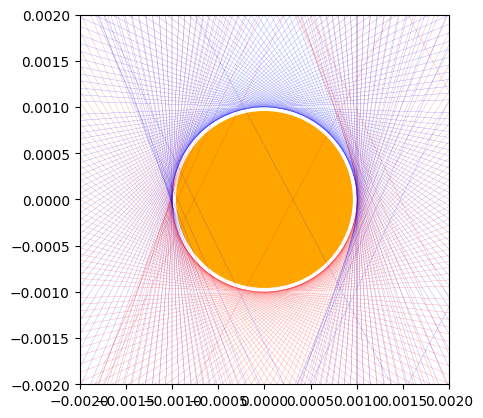

In [80]:
extreme1 = np.loadtxt('data_finite/extreme1.csv', delimiter = ',')
extreme2 = np.loadtxt('data_finite/extreme2.csv', delimiter = ',')

if flat_target: plt.plot([0, 0], [-radius, radius], linewidth = 5, color = 'orange', label = 'target')
else: plt.gca().add_patch(plt.Circle((0, 0), 0.95 * radius, color = 'orange', label = 'target'))

for row in extreme1: plt.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.1, c = 'red')
for row in extreme2: plt.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.1, c = 'blue')

plt.axis('square')
zoom = 2 * radius
plt.axis([-zoom, zoom, -zoom, zoom])
plt.show()

---

# Phase Space

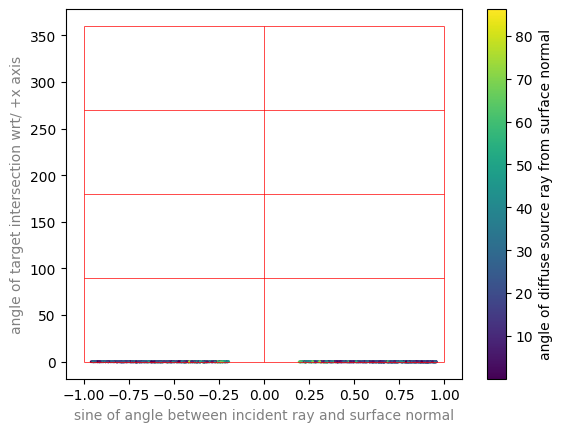

In [81]:
phase = np.loadtxt('data_finite/phase.csv', delimiter = ',')

plt.scatter(phase[:, 0], phase[:, 1], s = 1, c = phase[:, 2])

plt.xlabel("sine of angle between incident ray and surface normal", c = 'grey')
if flat_target: plt.ylabel("y-coordinate of target intersection", c = 'grey')
else: plt.ylabel("angle of target intersection wrt/ +x axis", c = 'grey')

if flat_target: plt.hlines(y = [-radius, 0, radius], xmin = -1, xmax = 1, linewidth = 0.5, color = 'r')
else: plt.hlines(y = [0, 90, 180, 270, 360], xmin = -1, xmax = 1, linewidth = 0.5, color = 'r')
if flat_target: plt.vlines(x = [-1, 0, 1], ymin = -radius, ymax = radius, linewidth = 0.5, color = 'r')
else: plt.vlines(x = [-1, 0, 1], ymin = 0, ymax = 360, linewidth = 0.5, color = 'r')

plt.colorbar(label = "angle of diffuse source ray from surface normal")
plt.show()

---

# Hit Ratio

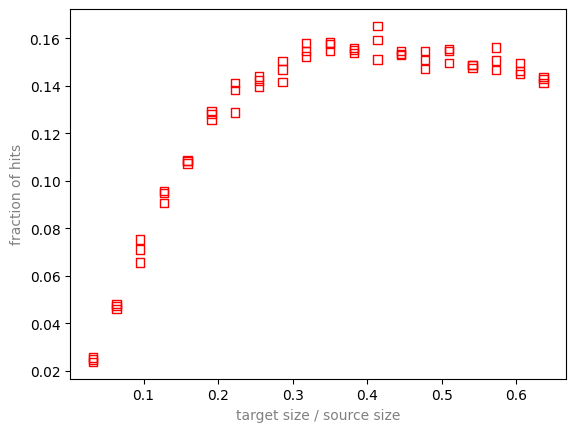

In [82]:
hit_data = np.loadtxt('data_finite/hitratio.csv', delimiter = ',')
plt.scatter(hit_data[:,0], hit_data[:,1], marker = 's', facecolors = 'none', edgecolors = 'r')
plt.xlabel("target size / source size", color = 'grey')
plt.ylabel("fraction of hits", color = 'grey')
plt.show()